In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, END, START

from typing import Annotated
from langgraph.graph.message import add_messages

In [8]:
class State(TypedDict):
    messages: Annotated[list, add_messages] #add_messages acts as a reducer. add_messages appends the messages to the list


In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

In [7]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model = "llama-3.3-70b-versatile"
)
llm.invoke("Hello")

AIMessage(content="Hello. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 36, 'total_tokens': 61, 'completion_time': 0.042143199, 'completion_tokens_details': None, 'prompt_time': 0.003439372, 'prompt_tokens_details': None, 'queue_time': 0.158606288, 'total_time': 0.045582571}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9483-38f7-7a32-8827-fb925414447b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 25, 'total_tokens': 61})

In [9]:
def superbot(state: State):
    return {"messages": [llm.invoke(state['messages'])]}

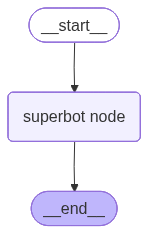

In [10]:
graph = StateGraph(State)

graph.add_node("superbot node", superbot)

graph.add_edge(START, "superbot node")
graph.add_edge("superbot node", END)

graph_builder = graph.compile()

#Display the graph
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
res = graph_builder.invoke({"messages": ["Who won 2024 T20 world cup?"]})

In [13]:
res

{'messages': [HumanMessage(content='Who won 2024 T20 world cup?', additional_kwargs={}, response_metadata={}, id='ff3cf8c0-4213-4407-9e87-0cbb7931a14c'),
  AIMessage(content="Since the 2024 T20 World Cup has not yet occurred, I do not have information on the winner. The 2024 ICC Men's T20 World Cup is scheduled to take place in the West Indies and the United States from June 4 to June 22, 2024. I'll be happy to provide more information once the event has concluded.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 75, 'prompt_tokens': 45, 'total_tokens': 120, 'completion_time': 0.258020432, 'completion_tokens_details': None, 'prompt_time': 0.010454737, 'prompt_tokens_details': None, 'queue_time': 0.159176449, 'total_time': 0.268475169}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9488-0364-7733-815e-5d690042

In [14]:
#Streaming the response
graph_builder.stream({"messages": ["hey there how is it going?"]})

<generator object Pregel.stream at 0xb0b7aa090>

In [15]:
for event in graph_builder.stream({"messages": ["hey there how is it going?"]}):
    print(event)

{'superbot node': {'messages': [AIMessage(content="Hello.  I'm doing well, thanks for asking. It's nice to chat with you. Is there something I can help you with or would you like to just talk for a bit?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 40, 'prompt_tokens': 42, 'total_tokens': 82, 'completion_time': 0.110419721, 'completion_tokens_details': None, 'prompt_time': 0.001447658, 'prompt_tokens_details': None, 'queue_time': 0.162588263, 'total_time': 0.111867379}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_4f6d808339', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9489-b125-75d2-bdd4-499b53c400a6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 40, 'total_tokens': 82})]}}


In [16]:
for event in graph_builder.stream({"messages": ["hey there how is it going?"]}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='hey there how is it going?', additional_kwargs={}, response_metadata={}, id='f1bc783e-3f30-4b87-a3d0-5a1fe5e2080c')]}
{'messages': [HumanMessage(content='hey there how is it going?', additional_kwargs={}, response_metadata={}, id='f1bc783e-3f30-4b87-a3d0-5a1fe5e2080c'), AIMessage(content="It's going well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you, how's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 61, 'prompt_tokens': 42, 'total_tokens': 103, 'completion_time': 0.104296357, 'completion_tokens_details': None, 'prompt_time': 0.002473162, 'prompt_tokens_details': None, 'queue_time': 0.157454444, 'total_time': 0.106769519}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish

In [18]:
for event in graph_builder.stream({"messages": ["hey there how is it going?"]}, stream_mode="updates"):
    print(event)

{'superbot node': {'messages': [AIMessage(content="Hello! I'm doing well, thanks for asking. It's great to connect with you. How about you, how's your day going so far? Is there anything I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 42, 'total_tokens': 89, 'completion_time': 0.116945923, 'completion_tokens_details': None, 'prompt_time': 0.001974646, 'prompt_tokens_details': None, 'queue_time': 0.160091714, 'total_time': 0.118920569}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_4f6d808339', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d948b-07aa-7791-9424-3198748c2575-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 42, 'output_tokens': 47, 'total_tokens': 89})]}}
